# Linear Regression on Network Traffic

In this hands-on assignment, we will explore learn models, in particular linear regression. Linear models can work well when there is a linear relationship between the target variable being predicted and the input features. In other words, when the target prediction can be modeled as a linear combination of the input features, linear models may be appropriate.

We'll explore the relationship beween bytes and packets in this hands-on, which may have a linear relationship at times. We will also explore how basis expansion---in particular polynomial basis expansion---can allow linear regression to fit more complex relationships between features and targets.

In [7]:
# Machine Learning Libraries
import numpy as np
import pandas as pd
from sklearn import linear_model

import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

import sys
sys.path.insert(1,"/Users/feamster/research/netml/src/")
from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

# Plotting Library
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (8,6)

from sklearn.preprocessing import PolynomialFeatures


## Part 1: Simple Linear Regression.

### Group Traffic Info Flows 

This example below uses a packet capture that is provided in the repository. You are also welcome (and encouraged!) to capture your own traffic.

Use `netml` to load the pcap and convert packets to flows, using pcap2flows.

In [8]:
hpcap = PCAP('data/http.pcap', flow_ptks_thres=2, verbose=10)
hpcap.pcap2flows()
len(hpcap.flows)

pcap_file: data/http.pcap
ith_packets: 0
ith_packets: 10000
ith_packets: 20000
len(flows): 593
total number of flows: 593. Num of flows < 2 pkts: 300, and >=2 pkts: 293 without timeout splitting.
kept flows: 293. Each of them has at least 2 pkts after timeout splitting.
flow_durations.shape: (293, 1)
        col_0
count 293.000
mean   11.629
std    15.820
min     0.000
25%     0.076
50%     0.455
75%    20.097
max    46.235
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col_0   293 non-null    float64
dtypes: float64(1)
memory usage: 2.4 KB
None
0th_flow: len(pkts): 4
After splitting flows, the number of subflows: 291 and each of them has at least 2 packets.


291

### Generate Features

Use the `netml` "STATS" option to generate features for each flow, which will provide the following features for each flow:

0. Duration
1. Packets per second
2. Bytes per second
3. Mean packet size
4. Standard deviation of packet sizes
5. 25th, median, 75th, min, max packet sizes

The exercise below requires a [slight modification](https://github.com/chicago-cdac/netml/pull/16/commits/79c0f930f2882c7bf042a9eb45e2a6ac413a695d) to the `netml` library (for versions <= 0.2.1) to add two additional features:
* number of packets per flow
* number of bytes per flow

You can modify the library (line 455 of `parser.py`) to add total number of packets and bytes per flow, or optionally explore the relationships between some of the other features.

### Train Model

Explore the relationship between some of these features. A natural one to explore is the relationship between the number of bytes in a flow and the number of packets in a flow.

Train a `Linear Regression` model from scikit learn to model this relationship, and output the resulting predictions into a vector `y_hat`.

### Visualize Your Model

Plot the relationship that your model has learned, by plotting the learned model (which should be a line), along with the points.  Label your axes!

What do you notice about the relationship, and how it relates to the original points?

### Evaluation: Error Computation

You can compute how well your manual fit is by computing the error, in terms of residual sum of squares.

## Part 2: Polynomial Basis Expansion

Recall that one of the benefits of a polynomial feature expansion is that it is possible to fit a linear model to a resulting polynomial expansion of the features.

We will do that below.  Let's first create the regular features and then the polynomial expansion. You will need the `PolynomialFeatures` library from `sklearn.preprocessing`, as well as the `fit_transform` function to generate your feature expansion.

In [9]:
# create regular features
hpcap.pcap2flows()
hpcap.flow2features('STATS', fft=False, header=False)

X = hpcap.features                      # (291, 12)

cols = ['duration', 'pkts_rate', 'bytes_rate',
        'size_mean', 'size_std', 'size_q1', 'size_q2', 'size_q3',
        'size_min', 'size_max', 'n_pkts', 'n_bytes']

df = pd.DataFrame(X, columns=cols)
df.to_csv('features_stats.csv', index=False)
print(X.shape)
df.head()


pcap_file: data/http.pcap
ith_packets: 0
ith_packets: 10000
ith_packets: 20000
len(flows): 593
total number of flows: 593. Num of flows < 2 pkts: 300, and >=2 pkts: 293 without timeout splitting.
kept flows: 293. Each of them has at least 2 pkts after timeout splitting.
flow_durations.shape: (293, 1)
        col_0
count 293.000
mean   11.629
std    15.820
min     0.000
25%     0.076
50%     0.455
75%    20.097
max    46.235
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col_0   293 non-null    float64
dtypes: float64(1)
memory usage: 2.4 KB
None
0th_flow: len(pkts): 4
After splitting flows, the number of subflows: 291 and each of them has at least 2 packets.
True
(291, 12)


,duration,pkts_rate,bytes_rate,size_mean,size_std,size_q1,size_q2,size_q3,size_min,size_max,n_pkts,n_bytes
0,30.076,0.133,11.637,87.500,21.500,66.000,87.500,109.000,66.000,109.000,4.000,350.000
1,30.060,0.133,11.444,86.000,20.000,66.000,86.000,106.000,66.000,106.000,4.000,344.000
2,40.960,0.122,8.057,66.000,0.000,66.000,66.000,66.000,66.000,66.000,5.000,330.000
3,40.962,0.122,8.056,66.000,0.000,66.000,66.000,66.000,66.000,66.000,5.000,330.000
4,0.058,34.661,2738.204,79.000,13.000,72.500,79.000,85.500,66.000,92.000,2.000,158.000


In [10]:
# Polynomial expansion
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)         # (291, 90)

df_poly = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(cols))
df_poly.to_csv('features_poly2.csv', index=False)
print(X_poly.shape)
df_poly.head()

(291, 90)


,duration,pkts_rate,bytes_rate,size_mean,size_std,size_q1,size_q2,size_q3,size_min,size_max,n_pkts,n_bytes,duration^2,duration pkts_rate,duration bytes_rate,duration size_mean,duration size_std,duration size_q1,duration size_q2,duration size_q3,duration size_min,duration size_max,duration n_pkts,duration n_bytes,pkts_rate^2,pkts_rate bytes_rate,pkts_rate size_mean,pkts_rate size_std,pkts_rate size_q1,pkts_rate size_q2,pkts_rate size_q3,pkts_rate size_min,pkts_rate size_max,pkts_rate n_pkts,pkts_rate n_bytes,bytes_rate^2,bytes_rate size_mean,bytes_rate size_std,bytes_rate size_q1,bytes_rate size_q2,bytes_rate size_q3,bytes_rate size_min,bytes_rate size_max,bytes_rate n_pkts,bytes_rate n_bytes,size_mean^2,size_mean size_std,size_mean size_q1,size_mean size_q2,size_mean size_q3,size_mean size_min,size_mean size_max,size_mean n_pkts,size_mean n_bytes,size_std^2,size_std size_q1,size_std size_q2,size_std size_q3,size_std size_min,size_std size_max,size_std n_pkts,size_std n_bytes,size_q1^2,size_q1 size_q2,size_q1 size_q3,size_q1 size_min,size_q1 size_max,size_q1 n_pkts,size_q1 n_bytes,size_q2^2,size_q2 size_q3,size_q2 size_min,size_q2 size_max,size_q2 n_pkts,size_q2 n_bytes,size_q3^2,size_q3 size_min,size_q3 size_max,size_q3 n_pkts,size_q3 n_bytes,size_min^2,size_min size_max,size_min n_pkts,size_min n_bytes,size_max^2,size_max n_pkts,size_max n_bytes,n_pkts^2,n_pkts n_bytes,n_bytes^2
0,30.076,0.133,11.637,87.500,21.500,66.000,87.500,109.000,66.000,109.000,4.000,350.000,904.587,4.000,350.000,2631.681,646.642,1985.040,2631.681,3278.323,1985.040,3278.323,120.305,10526.726,0.018,1.548,11.637,2.859,8.778,11.637,14.496,8.778,14.496,0.532,46.548,135.421,1018.242,250.197,768.045,1018.242,1268.438,768.045,1268.438,46.548,4072.966,7656.250,1881.250,5775.000,7656.250,9537.500,5775.000,9537.500,350.000,30625.000,462.250,1419.000,1881.250,2343.500,1419.000,2343.500,86.000,7525.000,4356.000,5775.000,7194.000,4356.000,7194.000,264.000,23100.000,7656.250,9537.500,5775.000,9537.500,350.000,30625.000,11881.000,7194.000,11881.000,436.000,38150.000,4356.000,7194.000,264.000,23100.000,11881.000,436.000,38150.000,16.000,1400.000,122500.000
1,30.060,0.133,11.444,86.000,20.000,66.000,86.000,106.000,66.000,106.000,4.000,344.000,903.577,4.000,344.000,2585.122,601.191,1983.931,2585.122,3186.314,1983.931,3186.314,120.238,10340.490,0.018,1.523,11.444,2.661,8.783,11.444,14.105,8.783,14.105,0.532,45.776,130.964,984.179,228.879,755.300,984.179,1213.058,755.300,1213.058,45.776,3936.717,7396.000,1720.000,5676.000,7396.000,9116.000,5676.000,9116.000,344.000,29584.000,400.000,1320.000,1720.000,2120.000,1320.000,2120.000,80.000,6880.000,4356.000,5676.000,6996.000,4356.000,6996.000,264.000,22704.000,7396.000,9116.000,5676.000,9116.000,344.000,29584.000,11236.000,6996.000,11236.000,424.000,36464.000,4356.000,6996.000,264.000,22704.000,11236.000,424.000,36464.000,16.000,1376.000,118336.000
2,40.960,0.122,8.057,66.000,0.000,66.000,66.000,66.000,66.000,66.000,5.000,330.000,1677.702,5.000,330.000,2703.344,0.000,2703.344,2703.344,2703.344,2703.344,2703.344,204.799,13516.721,0.015,0.983,8.057,0.000,8.057,8.057,8.057,8.057,8.057,0.610,40.283,64.910,531.741,0.000,531.741,531.741,531.741,531.741,531.741,40.283,2658.707,4356.000,0.000,4356.000,4356.000,4356.000,4356.000,4356.000,330.000,21780.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,4356.000,4356.000,4356.000,4356.000,4356.000,330.000,21780.000,4356.000,4356.000,4356.000,4356.000,330.000,21780.000,4356.000,4356.000,4356.000,330.000,21780.000,4356.000,4356.000,330.000,21780.000,4356.000,330.000,21780.000,25.000,1650.000,108900.000
3,40.962,0.122,8.056,66.000,0.000,66.000,66.000,66.000,66.000,66.000,5.000,330.000,1677.888,5.000,330.000,2703.494,0.000,2703.494,2703.494,2703.494,2703.494,2703.494,204.810,13517.469,0.015,0.983,8.056,0.000,8.056,8.056,8.056,8.056,8.056,0.610,40.281,64.903,531.712,0.000,531.712,531.712,531.712,531.712,531.712,40.281,2658.560,4356.000,0.000,4356.000,4356.000,4356.000,4356.000,4356.000,330.000

Train the linear regression model on the expanded set of features, and generate a new set of predictions, `y_hat_poly`.

In [11]:
from sklearn.metrics import r2_score, mean_squared_error

X = df[['n_pkts']].values     # df = features_stats.csv from before
y = df['n_bytes'].values

# linear
lin = linear_model.LinearRegression().fit(X, y)
y_at = lin.predict(X)

# degree-2 polynomial
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
lin_poly = linear_model.LinearRegression().fit(X_poly, y)
y_at_poly = lin_poly.predict(X_poly)

for name, yh in [('linear', y_at), ('poly2', y_at_poly)]:
    print(f"{name}: R2={r2_score(y, yh):.4f}  RMSE={mean_squared_error(y, yh)**0.5:.1f}")

linear: R2=0.9903  RMSE=50987.4
poly2: R2=0.9918  RMSE=46744.6


Visualize your results again. What do you notice about the predicted values?

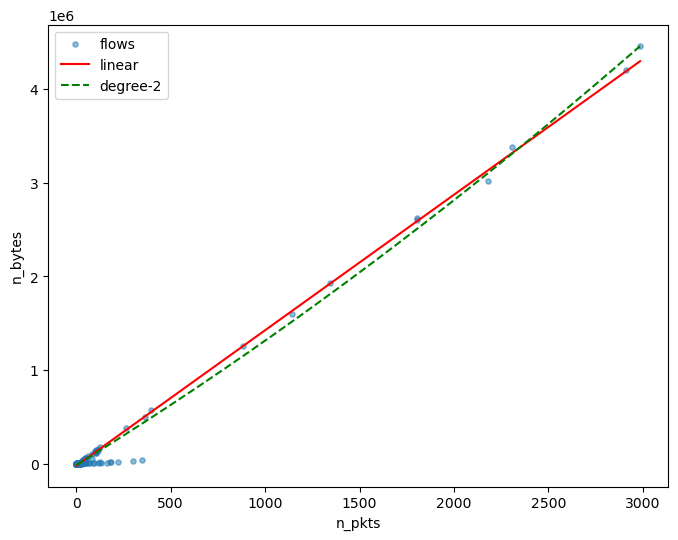

In [12]:
xg = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
plt.scatter(X, y, s=14, alpha=.5, label='flows')
plt.plot(xg, lin.predict(xg), 'r-', label='linear')
plt.plot(xg, lin_poly.predict(poly.transform(xg)), 'g--', label='degree-2')
plt.xlabel('n_pkts'); plt.ylabel('n_bytes'); plt.legend()

Evaluate your error once again. What happened to overall mean squared error?

In [13]:
from sklearn.metrics import mean_squared_error

mse_lin  = mean_squared_error(y, y_at)
mse_poly = mean_squared_error(y, y_at_poly)

print(f"linear MSE: {mse_lin:.2f}   RMSE: {mse_lin**0.5:.2f}")
print(f"poly2  MSE: {mse_poly:.2f}   RMSE: {mse_poly**0.5:.2f}")

linear MSE: 2599714165.31   RMSE: 50987.39
poly2  MSE: 2185055900.11   RMSE: 46744.58


The overall mean squared error lessened with more features. It dropped about 16%.

## Part 3: Exploring Relationships between Other Features

In the earlier parts of this hands-on, we explored simple relationship between features and outcome variables. You can extend your analysis by exploring other relationships, such as the relationships between one or more of the features already output from `netml`.

## Bonus: Reducing Error on Test Set

In the above example, we used a polynomial basis expansion to reduce the error on the training set. But, we have no test set, so it is difficult to tell whether the model above is overfit to the training data.

In order for us to tell whether this model is a good fit, we need to test it on data that the model has not yet seen. This requires splitting the data into a training set and a test set.

A typical split between training data and test data might be 80% training data, 20% test data. You can also perform this process repeatedly and average the results. This process is called **cross-validation**.

### Part 1

1. Take a packet trace using wireshark and load it into the notebook.
2. Perform a simple linear regression fit and a fit with basis expansion (same as above), comparing errors.

The first two steps are the same as above, but you might try doing this for a larger sample so that your network traffic has more flows (i.e., data points).

### Part 2

3. Use functions from sklearn to split the data into training and testing. (train_test_split, or sklearn's CV function).
4. How does model accuracy compare for different polynomial basis expansions? (n=1, 2, 3, ?) At what point is the model overfit?
5. Can you experiment with a regularization parameter to control or reduce overfitting?